In [1]:
import numpy as np
import os
import torch
import pandas as pd

from ophir.ticker import StockStreamerDataset, StockHanlder, get_sp_500_symbols, extract_model_data
from torch.utils.data import DataLoader
from ophir.register import fetch_base_trainer, fetch_finetune_trainer, load_base_model_ckpt, load_fintuned_ckpt
from ophir.model_data import OHLCMulitClassPredictorInput
import tqdm
from ophir.ticker import get_splits


torch.set_float32_matmul_precision("high")

sp_500 = get_sp_500_symbols()
splits = None  # get_splits()

base_path = "/home/kalen/ophir/ophir/.ophir/data/days/stocks"
elements_per_sample = 365
response_size = 90
offset = 1

val_stock_handler = StockHanlder(
    seq_len=elements_per_sample,
    base_path=base_path,
    return_stock_id=False,
    return_streamer=True,
    stock_splits=splits,
    offset=offset,
    # min_year=2024,
    # max_year=2025,
    min_volume=1000,
    winsorize_returns=True,
)
val_stock_handler.keep_stocks(sp_500)

stock_streamer = val_stock_handler["AAPL"]
dataset = StockStreamerDataset([stock_streamer], response_size=response_size, return_date=True)


/home/kalen/miniforge3/envs/ophir/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


stocks kept: 502/34700, stocks not found: 0


In [2]:
model, ckpt_path = load_base_model_ckpt(return_ckpt_path=True, time_version=True)
model = model.cuda()

# model_output = model(dataset[0])
# model_output

loading ophir-ohlc-base-time-check-v4.ckpt


<Axes: xlabel='time'>

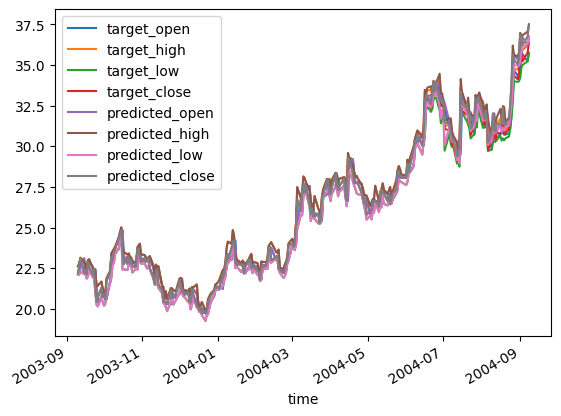

In [ ]:
output = model(extract_model_data(val_stock_handler["AAPL"].preprocessed_ohlc_df[:365], response_size=90, return_date=True))
df = val_stock_handler["AAPL"].get_ohlcs(output.to_pandas()[0])
# # outputs = []
# for i in range(len(dataset)):
#     outputs.append(model(dataset[len(dataset) - 1]))

# dfs = []
# for output in outputs:
#     dfs.append(output.to_pandas())
# pd.concat(dfs)  # drop_duplicates()
# df = output.ohlcs(output.to_pandas(), 100)
df[
    [
        "target_open",
        "target_high",
        "target_low",
        "target_close",
        "predicted_open",
        "predicted_high",
        "predicted_low",
        "predicted_close",
    ]
].plot()

In [1]:
import plotly.graph_objects as go

from ophir.ui import get_ohlc

elements_per_sample = 365
response_size = 90
offset = 90

val_stock_handler = StockHanlder(
    seq_len=elements_per_sample,
    base_path=base_path,
    return_stock_id=False,
    return_streamer=True,
    stock_splits=splits,
    offset=offset,
    min_year=2024,
    min_volume=1000,
    winsorize_returns=True,
)
val_stock_handler.keep_stocks(sp_500)
stock_streamers = {}
model, ckpt_path = load_base_model_ckpt(return_ckpt_path=True, time_version=True)
model = model.cuda()


def _f():
    empbeddings = []
    r_closes = []
    for stock in tqdm.tqdm(val_stock_handler.stocks):
        ohlcs, model_outputs = get_ohlc(stock)  # embeddings: np.ndarray
        if len(ohlcs) < 250:
            print(f"{stock} only has {len(ohlcs)}/{response_size} history.")
        else:
            r_closes.append(model_outputs.predicted_r_close)
            empbeddings.append(model_outputs.stock_embeddings)

    # Concatenate along the sample axis and force float32
    r_closes = torch.concatenate(r_closes, dim=1).mean(1).squeeze(-1).cpu().numpy()
    all_embeds = torch.concatenate(empbeddings, dim=0)

    # ------------------------------------------------------------------
    # 2️⃣  PCA to 3 components
    # ------------------------------------------------------------------
    normalized_embeddings = (all_embeds - all_embeds.mean(0, keepdims=True)) / (
        torch.linalg.norm(all_embeds, dim=-1, keepdim=True) + 1e-8
    )
    U, S, V = torch.pca_lowrank(normalized_embeddings, q=3)  # U: (N, 3), V: (D, 3)

    transformed = torch.matmul(normalized_embeddings, V)
    centered = transformed - transformed.mean(0, keepdims=True)
    centered = centered.detach().cpu().numpy()
    # ------------------------------------------------------------------
    # 3️⃣  Build the trace
    # ------------------------------------------------------------------
    closes = np.concatenate([ohlc["close"] for ohlc in ohlcs]).mean(1).reshape(-1)
    trace = go.Scatter3d(
        x=centered[:, 0],
        y=centered[:, 1],
        z=centered[:, 2],
        mode="markers",
        marker=dict(
            size=5,
            opacity=0.8,
            # If you want a colour‑map, uncomment the next line:
            color=closes,  # mean close, make sure this is numpy
            colorscale="Viridis",
            showscale=True,  # show a color bar
            colorbar=dict(title="r_close"),
            cmin=np.percentile(r_closes, 5),
            cmax=np.percentile(r_closes, 95),
        ),
    )

    # ------------------------------------------------------------------
    # 4️⃣  Assemble the figure
    # ------------------------------------------------------------------
    fig = go.Figure(data=[trace])

    # ------------------------------------------------------------------
    # 5️⃣  Dark‑theme styling
    # ------------------------------------------------------------------
    fig.update_layout(
        template="plotly_dark",
        scene=dict(
            xaxis=dict(title="PC 1", backgroundcolor="rgba(0,0,0,0)"),
            yaxis=dict(title="PC 2", backgroundcolor="rgba(0,0,0,0)"),
            zaxis=dict(title="PC 3", backgroundcolor="rgba(0,0,0,0)"),
            aspectmode="cube",  # keeps the axes proportional
        ),
        margin=dict(l=0, r=0, t=0, b=0),
        dragmode="orbit",
    )

    # Hide the grid lines (if you prefer a cleaner look)
    fig.update_layout(
        scene=dict(
            # X‑axis
            xaxis=dict(
                showticklabels=False,  # no labels
                showgrid=False,  # no grid
                zeroline=False,  # no zero line
                showline=False,  # hide the axis line (the “bar”)
                showspikes=False,
                ticks="",  # no tick marks
            ),
            # Y‑axis
            yaxis=dict(
                showticklabels=False,
                showgrid=False,
                zeroline=False,
                showline=False,
                showspikes=False,
                ticks="",
            ),
            # Z‑axis
            zaxis=dict(
                showticklabels=False,
                showgrid=False,
                zeroline=False,
                showline=False,
                showspikes=False,
                ticks="",
            ),
            # Keep the aspect ratio proportional to the data
            aspectmode="data",
        ),
    )

    # Set a fixed camera view so the plot looks the same every time
    fig.update_layout(scene_camera=dict(eye=dict(x=1.5, y=1.5, z=1.5)))

    return fig

stocks kept: 502/34700, stocks not found: 0
loading ophir-ohlc-base-time-check-v4.ckpt
creating block mask of size 365 with response size 90...


/home/kalen/miniforge3/envs/ophir/lib/python3.10/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
 14%|█▍        | 72/502 [00:02<00:12, 33.63it/s]

creating block mask of size 345 with response size 90...
XYZ only has 239/90 history.


 40%|███▉      | 200/502 [00:06<00:09, 30.71it/s]

creating block mask of size 51 with response size 90...


...

creating block mask of size 59 with response size 90...
Q only has 41/90 history.


 82%|████████▏ | 412/502 [00:13<00:02, 32.90it/s]

creating block mask of size 311 with response size 90...
SNDK only has 216/90 history.


100%|██████████| 502/502 [00:16<00:00, 30.69it/s]


TypeError: string indices must be integers

In [20]:
closes

NameError: name 'closes' is not defined

In [ ]:
sorted(list(val_stock_handler.stocks))


['A',
 'AAPL',
 'ABBV',
 'ABNB',
 'ABT',
 'ACGL',
 'ACN',
 'ADBE',
 'ADI',
 'ADM',
 'ADP',
 'ADSK',
 'AEE',
 'AEP',
 'AES',
 'AFL',
 'AIG',
 'AIZ',
 'AJG',
 'AKAM',
 'ALB',
 'ALGN',
 'ALL',
 'ALLE',
 'AMAT',
 'AMCR',
 'AMD',
 'AME',
 'AMGN',
 'AMP',
 'AMT',
 'AMZN',
 'ANET',
 'AON',
 'AOS',
 'APA',
 'APD',
 'APH',
 'APO',
 'APP',
 'APTV',
 'ARE',
 'ARES',
 'ATO',
 'AVB',
 'AVGO',
 'AVY',
 'AWK',
 'AXON',
 'AXP',
 'AZO',
 'BA',
 'BAC',
 'BALL',
 'BAX',
 'BBY',
 'BDX',
 'BEN',
 'BF.B',
 'BG',
 'BIIB',
 'BK',
 'BKNG',
 'BKR',
 'BLDR',
 'BLK',
 'BMY',
 'BR',
 'BRK.B',
 'BRO',
 'BSX',
 'BX',
 'BXP',
 'C',
 'CAG',
 'CAH',
 'CARR',
 'CAT',
 'CB',
 'CBOE',
 'CBRE',
 'CCI',
 'CCL',
 'CDNS',
 'CDW',
 'CEG',
 'CF',
 'CFG',
 'CHD',
 'CHRW',
 'CHTR',
 'CI',
 'CINF',
 'CL',
 'CLX',
 'CMCSA',
 'CME',
 'CMG',
 'CMI',
 'CMS',
 'CNC',
 'CNP',
 'COF',
 'COIN',
 'COO',
 'COP',
 'COR',
 'COST',
 'CPAY',
 'CPB',
 'CPRT',
 'CPT',
 'CRH',
 'CRL',
 'CRM',
 'CRWD',
 'CSCO',
 'CSGP',
 'CSX',
 'CTAS',
 'CTRA',
 '

TypeError: Dropdown.__init__() got an unexpected keyword argument 'placeholder'

In [ ]:

for output in outputs:

[OHLCMulitClassPredictorInput(feature_input=tensor([[[ 1.3863, -0.0085, -0.4714,  ...,  0.0126,  0.0071,  0.0033],
          [ 0.0000, -0.0070, -0.3932,  ...,  0.0126,  0.0030,  0.0036],
          [ 0.0000,  0.0048,  0.2786,  ...,  0.0126,  0.0061,  0.0063],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 1.0986,  0.0192,  1.2725,  ...,  0.0183,  0.0156,  0.0269]]],
        device='cuda:0'), response_size=tensor(90), trade_occured=tensor([[ True,  True,  True,  True,  True, False, False,  True,  True,  True,
           True,  True, False, False,  True,  True,  True,  True,  True, False,
          False,  True,  True,  True,  True,  True, False, False,  True,  True,
           True,  True,  True, False, False,  True,  True,  True,  True,  True,
          False, False,  True,  True,  True,  True,  True, False, False,  True,
           True,  True,  True,  True, False

In [5]:
model_output.time.shape, model_output.trade_occured.shape

((1, 365), torch.Size([1, 365]))

In [9]:
(502 * 365 * 21) // 64


60122

In [3]:
model_output.time.shape

(1, 365)

In [5]:
model_output.time.shape

(365,)

In [8]:
generated_response = model.generate_response(inputs, 1)
# generated_response

Using caching!!!
caching


100%|██████████| 90/90 [00:05<00:00, 17.22it/s]

clearing cache!!!


20


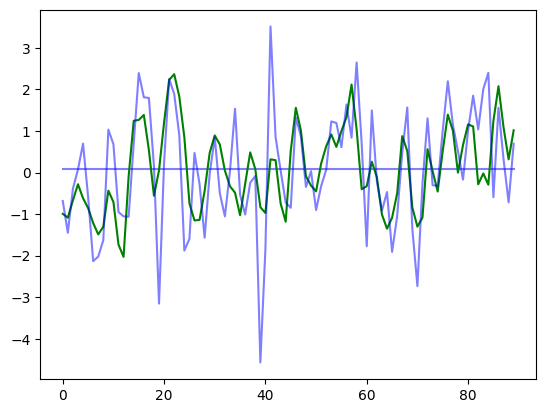

In [12]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt

stock_index = np.random.randint(batch_size)
print(stock_index)
ohlc_index = 0
show_response = False
if show_response:
    ohlc = generated_response.percentage_change.predicted_response_mu[stock_index].squeeze().detach().cpu().numpy()
    target_ohlc = generated_response.percentage_change.response_change[stock_index].squeeze().detach().cpu().numpy()
    xs = np.arange(target_ohlc.shape[0])

else:
    size = generated_response.percentage_change.response_size
    ohlc = generated_response.percentage_change.predicted_change_mu[stock_index, -size:].squeeze().detach().cpu().numpy()
    target_ohlc = generated_response.percentage_change.target_change[stock_index, -size:].squeeze().detach().cpu().numpy()
    xs = np.arange(target_ohlc.shape[0])
    # predicted_mean = (
    #     generated_response.percentage_change.predicted_expected_response_mu.squeeze()
    #     .detach()
    #     .cpu()
    #     .numpy()[stock_index, ohlc_index]
    # )
    # plt.plot([xs[0], xs[-1]], [predicted_mean, predicted_mean], color="green")

    target_mean = generated_response.percentage_change.expected_response_change.squeeze().detach().cpu().numpy()[stock_index]
    plt.plot([xs[0], xs[-1]], [target_mean, target_mean], "blue", alpha=0.5)

plt.plot(xs, ohlc, color="green")
plt.plot(xs, target_ohlc, "blue", alpha=0.5)


# plt.plot(np.arange(target_ohlc[-inputs.response_size:, 1].shape[0]), response_mask[-inputs.response_size:], "black")
# plt.plot(np.arange(target_ohlc[inputs.response_start - 1:, 1].shape[0]), np.exp(sigma[inputs.response_start - 1:, 1]), "red", alpha=0.5)
# fig = go.Figure(
#     data=go.Ohlc(
#         x=percentage_df["dates"],
#         open=percentage_df["open"],
#         high=percentage_df["high"],
#         low=percentage_df["low"],x
#         close=percentage_df["close"],
#     )
# )
# fig.show()

In [ ]:
24 * 60

1440

In [ ]:
inputs.minute

In [ ]:
generated_response.percentage_change.target_change.shape

In [ ]:
768 / 12

In [ ]:
(
    generated_response.percentage_change.expected_response_change,
    generated_response.percentage_change.predicted_expected_response_mu,
)

In [ ]:
appl.token_to_stock

In [ ]:
np.argwhere(target_ohlc == 0), inputs.response_start, inputs.response_size

In [ ]:
pca_embeddings = generated_response.stock_embeddings.pca_projection()
with open("model_embeddings.tsv", "w") as file:
    for pca_emb in:
        tensor_str = "\t".join([f"{elem}" for elem in tensor])
        file.write(f"{tensor_str}\n")

In [ ]:
x = torch.rand((6, 3, 2))
token = torch.ones((2)) * 5
pos = torch.randint(high=3, size=[6])


def insert_token_loop(x: torch.Tensor, token: torch.Tensor, pos: torch.Tensor) -> torch.Tensor:
    if token.dim() == 1:
        token = token.unsqueeze(0).expand(x.size(0), -1)

    return torch.stack([torch.cat([x[b, : pos[b]], token[b : b + 1], x[b, pos[b] :]], dim=0) for b in range(x.size(0))])


def remove_token_loop(x: torch.Tensor, pos: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.cat([x[b, : pos[b]], x[b, pos[b] + 1 :]], dim=0) for b in range(x.size(0))])


def extract_token_loop(x: torch.Tensor, pos: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.cat([x[b, pos[b] : pos[b] + 1]], dim=0) for b in range(x.size(0))])


remove_token_loop(insert_token_loop(x, token, pos), pos).shape

In [ ]:
x

In [ ]:
response_mask[-inputs.response_size :]

In [ ]:
ohlc.shape

In [ ]:
generated_response.percentage_change.smallest_change

In [ ]:
fig = go.Figure(
    data=go.Ohlc(
        x=target_percentage_df["dates"],
        open=target_percentage_df["open"],
        high=target_percentage_df["high"],
        low=target_percentage_df["low"],
        close=target_percentage_df["close"],
    )
)
fig.show()

In [ ]:
ohlc = generated_response.percentage_change.predicted_change_mu[stock_index].squeeze().detach().cpu().numpy()
percentage_df = pd.DataFrame(
    {
        # "dates": dates,
        "open": ohlc[:, 0],
        "high": ohlc[:, 1],
        "low": ohlc[:, 2],
        "close": ohlc[:, 3],
    }
)

target_ohlc = generated_response.percentage_change.target_change[stock_index].squeeze().detach().cpu().numpy()
target_percentage_df = pd.DataFrame(
    {
        # "dates": dates,
        "open": target_ohlc[:, 0],
        "high": target_ohlc[:, 1],
        "low": target_ohlc[:, 2],
        "close": target_ohlc[:, 3],
    }
)

plt.plot(np.arange(target_ohlc[-30:, 1].shape[0]), ohlc[-30:, 1], color="green")
plt.plot(np.arange(target_ohlc[-30:, 1].shape[0]), target_ohlc[-30:, 1], "blue")

In [ ]:
plt.plot(np.arange(30), model_output.reference_change[i][:, 0].squeeze().detach().cpu().numpy())
plt.plot(np.arange(30), model_output.target_reference_change[i][:, 0].squeeze().detach().cpu().numpy())

In [ ]:
import pandas as pd

pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv")

In [ ]:
data_loader.dataset.ignore_symbols = fetch_ignore_symbols_list()
output = trainer.predict(model, data_loader)
predicted_change = []
change = []
predicted_ohlc = []
ohlc = []
for model_output, batch in output:
    predicted_ohlc.append(model_output["predicted_ohlc"])
    ohlc.append(batch["ohlc"])
    predicted_change.append(model_output["predicted_response"]["reference_change"])
    change.append(batch["response"]["reference_change"])

import torch

predicted_change = torch.concat(predicted_change, dim=0).squeeze(-1)
change = torch.concat(change, dim=0).squeeze(-1)

predicted_change.shape, change.shape
residuals = (predicted_change - change).abs().mean((0, 2)).cpu().numpy()
plt.figure(figsize=(12, 12))
plt.bar(list(range(len(residuals))), residuals)
plt.plot(
    list(range(len(residuals))),
    np.zeros_like(residuals),
    color="black",
)
plt.xlabel("Day")
# plt.ylim(0, 1)
plt.ylabel("Avg. Absolute Residual")
plt.show()
plt.close()


In [ ]:
predicted_ohlc = torch.concat(predicted_ohlc, dim=0).squeeze(-1)
ohlc = torch.concat(ohlc, dim=0).squeeze(-1)

predicted_ohlc.shape, ohlc.shape
residuals = (predicted_ohlc - ohlc).abs().mean((0, 2)).cpu().numpy()
plt.figure(figsize=(12, 12))
plt.bar(list(range(len(residuals))), residuals)
plt.plot(
    list(range(len(residuals))),
    np.zeros_like(residuals),
    color="black",
)
plt.xlabel("Day")
# plt.ylim(0, 1)
plt.ylabel("Avg. Absolute Residual")
plt.show()
plt.close()

In [ ]:
ax = plt.subplot()
xs = np.arange(predicted_change.shape[1])
for pc, c in zip(predicted_change[:10], change[:10]):
    ax.plot(xs, pc[:, 0], color="red")
    ax.plot(xs, c[:, 0], color="blue")
plt.show()


In [ ]:
from ophir.ticker import TOKEN_INDUSTRY, TOKEN_SECTOR, TOKEN_SYMBOL

In [ ]:
def extract_embeddings(output):
    predicted_results = {
        "predicted_ohlc": [],
        "reference_change": [],
        "response_embedding": [],
        "local_class": [],
        "largest_pos": [],
        "smallest_pos": [],
        "Open Class": [],
        "Close Class": [],
        "High Class": [],
        "Low Class": [],
    }
    results = {
        "ohlc": [],
        "mask": [],
        "date": [],
        "symbol": [],
        "sector": [],
        "industry": [],
        "response_size": [],
        "bought_index": [],
        "response_indices": [],
        "reference_change": [],
        "local_class": [],
        "largest_index": [],
        "smallest_index": [],
    }

    for model_output, model_input in output:
        results["ohlc"].append(model_input["ohlc"].reshape((-1, 180)))
        predicted_results["predicted_ohlc"].append([model_output["predicted_ohlc"].reshape((-1, 180))])

        results["local_class"].append(model_input["response"]["local_class"].reshape((-1, 4)))
        predicted_results["local_class"].append(model_output["predicted_response"]["local_class"].reshape((-1, 4)))
    #     # pr = predicted_results["predicted_response"]
    #     # m_out = model_output["predicted_response"]
    #     predicted_results["reference_change"].append(
    #         model_output["predicted_response"]["reference_change"].squeeze()
    #     )
    #     predicted_results["response_embedding"].append(
    #         model_output["predicted_response"]["response_embedding"].squeeze()
    #     )
    #     predicted_results["Close Class"].append(model_output["predicted_response"]["local_class"])
    #     # pr["largest_pos"] += [m_out["largest_pos"].squeeze()]
    #     # pr["smallest_pos"] += [m_out["smallest_pos"].squeeze()]

    #     # inpute response
    #     # res_pr = results["response"]
    #     # model_in = model_input["response"]
    #     results["symbol"] += [model_input["stock_info"]["symbol"].squeeze()]
    #     results["sector"] += [model_input["stock_info"]["sector"].squeeze()]
    #     results["industry"] += [model_input["stock_info"]["industry"].squeeze()]
    #     results["reference_change"] += [model_input["response"]["reference_change"].squeeze()]
    #     results["local_class"] += [model_input["response"]["local_class"].squeeze()]
    #     # break
    #     # res_pr["largest_index"] += [model_in["largest"]["index"].squeeze()]
    #     # res_pr["smallest_index"] += [model_in["smallest"]["index"].squeeze()]
    # # pr = predicted_results["predicted_response"]
    # # m_out = model_output["predicted_response"]
    # # res_pr = results["response"]
    # # model_in = model_input["response"]

    # results["ohlc"] = torch.concatenate(results["ohlc"], dim=0).squeeze()
    # predicted_results["predicted_ohlc"] = torch.concatenate(
    #     predicted_results["predicted_ohlc"], dim=0
    # ).squeeze()
    # predicted_results["reference_change"] = torch.concatenate(
    #     predicted_results["reference_change"], dim=0
    # ).squeeze()
    # # pr["response_embedding"] = torch.concatenate(pr["response_embedding"], dim=0).squeeze()
    # predicted_results["local_class"] = torch.concatenate(
    #     predicted_results["local_class"], dim=0
    # ).squeeze()
    # # pr["largest_pos"] = torch.concatenate(pr["largest_pos"], dim=0).squeeze()
    # # pr["smallest_pos"] = torch.concatenate(pr["smallest_pos"], dim=0).squeeze()
    # results["symbol"] = torch.concatenate(results["symbol"], dim=0).squeeze()
    # results["sector"] = torch.concatenate(results["sector"], dim=0).squeeze()
    # results["industry"] = torch.concatenate(results["industry"], dim=0).squeeze()
    # results["reference_change"] = torch.concatenate(results["reference_change"], dim=0).squeeze()
    # results["local_class"] = torch.concatenate(results["local_class"], dim=0).squeeze()
    # # res_pr["largest_index"] = torch.concatenate(res_pr["largest_index"], dim=0).squeeze()
    # # res_pr["smallest_index"] = torch.concatenate(res_pr["smallest_index"], dim=0).squeeze()

    # # graph_data = {
    # #     "open": results["ohlc"][:, 0].numpy().tolist(),
    # #     "high": results["ohlc"][:, 1].numpy().tolist(),
    # #     "lo2": results["ohlc"][:, 2].numpy().tolist(),
    # #     "close": results["ohlc"][:, 3].numpy().tolist(),
    # #     "predicted_open": predicted_results["predicted_ohlc"][:, 0].numpy().tolist(),
    # #     "predicted_high": predicted_results["predicted_ohlc"][:, 1].numpy().tolist(),
    # #     "predicted_low": predicted_results["predicted_ohlc"][:, 2].numpy().tolist(),
    # #     "predicted_close": predicted_results["predicted_ohlc"][:, 3].numpy().tolist(),
    # # }
    # metadata_data = {
    #     "x": [],
    #     "y": [],
    #     "z": [],
    #     "Symbol": [TOKEN_SYMBOL[s] for s in results["symbol"].numpy().tolist()],
    #     "Sector": [TOKEN_SECTOR[s] for s in results["sector"].numpy().tolist()],
    #     "Industry": [TOKEN_INDUSTRY[s] for s in results["industry"].numpy().tolist()],
    #     "Largest Open": results["reference_change"][:, :, 0].numpy().max(axis=-1).tolist(),
    #     "Smallest Open": results["reference_change"][:, :, 0].numpy().min(axis=-1).tolist(),
    #     "Largest High": results["reference_change"][:, :, 1].numpy().max(axis=-1).tolist(),
    #     "Smallest High": results["reference_change"][:, :, 1].numpy().min(axis=-1).tolist(),
    #     "Largest Low": results["reference_change"][:, :, 2].numpy().max(axis=-1).tolist(),
    #     "Smallest Low": results["reference_change"][:, :, 2].numpy().min(axis=-1).tolist(),
    #     "Largest Close": results["reference_change"][:, :, 3].numpy().max(axis=-1).tolist(),
    #     "Smallest Close": results["reference_change"][:, :, 3].numpy().min(axis=-1).tolist(),
    #     "local_class": results["local_class"].numpy().tolist(),
    #     "predicted_response_class": predicted_results["local_class"].argmax(-1).numpy().tolist(),
    # }
    # embeddings = torch.concatenate(predicted_results["response_embedding"], dim=0)
    # pca = PCA()
    # with torch.no_grad():
    #     embeddings = pca.fit_transform(embeddings)
    #     embeddings = embeddings - embeddings.mean(dim=0)
    #     norm = torch.linalg.norm(embeddings, dim=-1, keepdim=True)
    #     embeddings = embeddings / norm

    # for embedding in embeddings[:, :3]:
    #     point = embedding.numpy().tolist()
    #     metadata_data["x"].append(point[0])
    #     metadata_data["y"].append(point[1])
    #     metadata_data["z"].append(point[2])
    # nearest_neighbors = embeddings @ torch.transpose(embeddings, 0, 1)
    # nearest_neighbors = torch.argsort(
    #     nearest_neighbors
    #     * torch.eye(nearest_neighbors.shape[0], device=nearest_neighbors.device, dtype=torch.bool),
    #     descending=True,
    # )
    # return metadata_data, embeddings, results, predicted_results
    return results["local_class"], predicted_results["local_class"]


In [ ]:
output[0][0]["predicted_ohlc"].reshape((-1, 180))
output[0][0]["predicted_response"]["local_class"].reshape((-1, 4))

In [ ]:
from torch_pca import PCA
from ophir.register import set_ignore_symbols

# data, model_embeddings, res, pred = extract_embeddings(output)
results, predicte_results = extract_embeddings(output)
torch.concatenate(results), torch.concatenate(predicte_results), predicte_results
# invalid = np.isnan(model_embeddings).sum(axis=-1) > 0
# with open("model_embeddings.tsv", "w") as file:
#     for i, tensor in enumerate(model_embeddings):
#         if not invalid[i]:
#             tensor_str = "\t".join([f"{elem}" for elem in tensor])
#             file.write(f"{tensor_str}\n")
# data = pd.DataFrame(data)
# data.to_csv("model_metadata.tsv", sep="\t", index=False)
# data
# filtered_df = data[data["global_class"] == 1295]
# bad_list = list(filtered_df["Symbol"].unique())
# len(bad_list)
# set_ignore_symbols(bad_list)

In [ ]:
import pandas as pd
import dateutil.parser
from datetime import datetime
import os

dir_path = "/home/kalen/ophir/ophir/.ophir/data/days"
day_agg_paths = sorted(os.listdir(dir_path))
tickers = None
for day_path in day_agg_paths:
    day_agg = pd.read_parquet(os.path.join(dir_path, day_path))
    day_agg["timestamp"] = day_agg["date"].apply(datetime.timestamp)
    day_agg.to_parquet(os.path.join(dir_path, day_path))

In [ ]:
df = pd.read_parquet("/home/kalen/ophir/ophir/.ophir/data/days/2008-01-02.parquet")
df

In [ ]:
len(data["Symbol"].unique()), len(filtered_df["Symbol"].unique())

In [ ]:
np.sum([res_cls * (6**i) for i, res_cls in enumerate([5, 5, 5, 5])])

In [ ]:
ignore_df = df[(~df.Symbol.isna()) & (df["response_class"] == 0)]


In [ ]:
ignore_df["Symbol"].to_list()

In [ ]:
output[0][1]["response"]["reference_change"].max(1)

In [ ]:
import datetime

dates = output[0][1]["date"]
dates = torch.concat([dates["year"].unsqueeze(-1), dates["month"].unsqueeze(-1), dates["day"].unsqueeze(-1)], dim=-1)
date_list = []


def tokens_to_date(date_tokens):
    year, month, day = date_tokens
    return datetime.date(year + 2008, month + 1, day + 1)


for sample_dates in dates:
    date_list.append([tokens_to_date(date_tokens) for date_tokens in sample_dates])
date_list

In [ ]:
batch["price"]

In [ ]:
# true_changes = target[0].cpu().numpy()  # first 180 in test set
# output = model_output[0].cpu().numpy()  # first 180 in test set
# plt.figure(figsize=(12, 12))
# plt.plot(
#     list(range(len(true_changes))),
#     true_changes,
#     color="g",
#     alpha=0.5,
# )
# plt.plot(
#     list(range(len(true_changes))),
#     np.zeros_like(true_changes),
#     color="black",
# )
# plt.plot(
#     list(range(len(output))),
#     output,
#     color="b",
# )
# plt.xlabel("Day")
# plt.ylim(-10, 10)
# plt.ylabel("Percentange Change")


# plt.show()
# plt.close()

In [ ]:
stock_to_token, _, sector_to_token, industry_to_token = get_stock_tokens()
token_to_stock = {token: symbol for symbol, token in stock_to_token.items()}
token_to_sector = {token: symbol for symbol, token in sector_to_token.items()}
token_to_sector[0] = "Unknown"
token_to_industry = {token: symbol for symbol, token in industry_to_token.items()}
token_to_industry[0] = "Unknown"

embeddings = []
data = {
    "predicted_class": [],
    "class": [],
    "predicted_largest_change": [],
    "largest_change": [],
    "predicted_smallest_change": [],
    "smallest_change": [],
    # "predicted_largest_position": [],
    # "largest_position": [],
    # "predicted_smallest_position": [],
    # "smallest_position": [],
    "sector": [],
    "industry": [],
    "stock": [],
    "reference_position": [],
}


def extract_predicted_actual(key, predicted_output, actual_output):
    for predicted, actual in zip(predicted_output, actual_output):
        if "class" not in key and "position" not in key:
            data[f"predicted_{key}"].append(predicted.squeeze().numpy())
            data[key].append(actual.squeeze().numpy())
        else:
            data[f"predicted_{key}"].append(torch.argmax(torch.softmax(predicted, dim=-1)).squeeze().numpy())
            data[key].append(actual.squeeze().numpy())


for model_output, batch in output:
    predicted_response = model_output["predicted_response"]
    batch_response = batch["response"]
    embeddings.append(predicted_response["response_embedding"])

    extract_predicted_actual("class", predicted_response["response_class"], batch_response["response_class"])
    extract_predicted_actual("largest_change", predicted_response["largest_change"], batch_response["largest"]["change"])
    extract_predicted_actual(
        "smallest_change",
        predicted_response["smallest_change"],
        batch_response["smallest"]["change"],
    )
    # extract_predicted_actual(
    #     "largest_position",
    #     predicted_response["largest_position"],
    #     batch_response["largest"]["position"],
    # )
    # extract_predicted_actual(
    #     "smallest_position",
    #     predicted_response["smallest_position"],
    #     batch_response["smallest"]["position"],
    # )

    stock_info = batch["stock_info"]
    for sector_token in stock_info["sector"]:
        data["sector"].append(token_to_sector[int(sector_token.numpy().squeeze())])

    for industry_token in stock_info["industry"]:
        data["industry"].append(token_to_industry[int(industry_token.numpy().squeeze())])

    for stock_token in stock_info["symbol"]:
        data["stock"].append(token_to_stock[int(stock_token.numpy().squeeze())])

    for reference in batch_response["bought_index"]:
        data["reference_position"].append(int(reference.squeeze().numpy()))
data = pd.DataFrame(data)


In [ ]:
from torch_pca import PCA

model_embeddings = torch.concatenate(embeddings, dim=0)

pca = PCA()
with torch.no_grad():
    model_embeddings = pca.fit_transform(model_embeddings)
    model_embeddings = model_embeddings - model_embeddings.mean(dim=0)
    norm = torch.linalg.norm(model_embeddings, dim=-1, keepdim=True)
    model_embeddings = model_embeddings / norm
    # embeddings = normalize_embeddings[:, :3]
model_embeddings @ torch.transpose(model_embeddings, 0, 1)
# model_embeddings = model_embeddings[:, :3].numpy()
# invalid = np.isnan(model_embeddings).sum(axis=-1) > 0
# with open("model_embeddings.tsv", "w") as file:
#     for i, tensor in enumerate(model_embeddings):
#         if not invalid[i]:
#             tensor_str = "\t".join([f"{elem}" for elem in tensor])
#             file.write(f"{tensor_str}\n")
# data.to_csv("model_metadata.tsv", sep="\t", index=False)

In [ ]:
distances = model_embeddings @ torch.transpose(model_embeddings, 0, 1)
diag_mask = torch.eye(distances.shape[0], device=distances.device, dtype=torch.bool)
torch.argsort(distances * ~diag_mask, dim=-1, descending=True)[:100]


In [ ]:
batch["response"]["reference_change"].shape

In [ ]:
norm_embeddings = model_embeddings / torch.linalg.norm(model_embeddings - model_embeddings.mean(dim=0), dim=-1, keepdim=True)

In [ ]:
# model_embeddings = torch.concatenate(embeddings, dim=0)


In [ ]:
x = torch.rand((2, 6, 1))
y = torch.rand((2, 6, 5))
max_index = torch.argmax(x, dim=1, keepdim=True)
(
    x,
    x.gather(dim=1, index=max_index),
    y.gather(dim=1, index=max_index.broadcast_to(-1, -1, y.shape[-1])),
)
# y.gather(dim=1, index=max_index.squeeze())

In [ ]:
import os

import pandas as pd

dir_path = "/home/kalen/ophir/ophir/.ophir/data/days (Copy)"
day_agg_paths = sorted(os.listdir(dir_path))
df = pd.read_parquet(os.path.join(dir_path, day_agg_paths[-1]))
df
# start = pd.to_datetime("2025-10-23").tz_localize("America/New_York")
# start_index = 0
# for i, day in enumerate(day_agg_paths):
#     if pd.to_datetime(day.split(".parquet")[0]).tz_localize("America/New_York") >= start:
#         start_index = i
#         break
# day_range = day_agg_paths[start_index : start_index + 180]
# day_range

In [ ]:
from massive import RESTClient

client = RESTClient("k3sqpiWZ0xxOVR4_U9QMCkrQWCE1hVFJ")

aggs = []
for a in client.list_aggs(
    "AAPL",
    1,
    "day",
    "2023-01-09",
    "2024-02-10",
    adjusted="true",
    sort="asc",
    limit=120,
):
    print(a)
    break

In [ ]:
import numpy as np
import pandas as pd

appl = pd.read_parquet("/home/kalen/ophir/ophir/.ophir/data/minutes/ADT.parquet")
appl

In [ ]:
random_day = np.random.randint(len(appl))
random_diff = (appl["date"] - appl.iloc[random_day]["date"]).dt.days
filtered_df = appl.loc[(np.abs(random_diff) < 150)]

In [ ]:
random_diff

In [ ]:
def compute_stride(filtered_df, num_groups):
    stride = filtered_df.shape[0] // num_groups
    if filtered_df.shape[0] / stride:
        


compute_stride(filtered_df, num_groups=301)

In [ ]:
date = appl.loc[(np.abs(random_diff) < 150)].iloc[::415]["date"]
date.index[0]

In [ ]:
import os

import pandas as pd

dir_path = "/home/kalen/ophir/ophir/.ophir/data/days"

print("loading tickers...")
day_agg_paths = sorted(os.listdir(dir_path))

day_info = []
close_prices = []
is_prev_ohlc = []
tickers = None
for day in day_agg_paths:
    day_agg = pd.read_parquet(os.path.join(dir_path, day))
    day_agg.loc[day_agg["is_prev_ohlc"].isna(), "is_prev_ohlc"] = False
    day_agg.to_parquet(os.path.join(dir_path, day))
    break

In [ ]:
minute_df = pd.read_parquet("/home/kalen/ophir/ophir/.ophir/data/minutes/2025-11-04.parquet")
minute_df[minute_df["ticker"] == "A"]

In [ ]:
1021 / 60

In [ ]:
import os
import pandas as pd

dir_path = "/home/kalen/ophir/ophir/.ophir/data/minutes"

print("loading tickers...")
day_agg_paths = sorted(os.listdir(dir_path))

tickers = []
for ticker_path in day_agg_paths:
    ticker = pd.read_parquet(os.path.join(dir_path, ticker_path), columns=["close", "date"])
    ticker["day"] = ticker["date"].dt.floor("D")
    break
ticker

In [ ]:
import numpy as np


def year_month_day(date):
    return np.vstack([date.dt.year, date.dt.month, date.dt.day, date.dt.hour, date.dt.minute])


ticker_days = ticker.groupby("day")
days = []
dates = []
prices = []
for day, df in ticker_days:
    days.append(day)
    prices.append(df.close.to_numpy())
    dates.append(year_month_day(df.date))

items_per_day = [len(p) for p in prices]
len(prices), len(dates), items_per_day
# ticker_pivot = ticker_pivot.iloc[:, 6:66]
# # Function to sample one non-NaN value from a Series (row)
# def sample_non_nan(row):
#     non_nan_values = row.dropna()
#     if not non_nan_values.empty:
#         return non_nan_values.sample(n=1)#.iloc[0]
#     else:
#         return np.nan # Return NaN if the row contains only NaNs

# # Apply the function to each row
# sample = ticker_pivot.apply(sample_non_nan, axis=0)
# dates = sample.index
# prices = sample.to_numpy().diagonal()
# dates, prices

In [ ]:
ticker_pivot = pd.pivot(ticker, index="date", values="close", columns="day")
ticker_pivot = ticker_pivot.iloc[:, 6:66]


# Function to sample one non-NaN value from a Series (row)
def sample_non_nan(row):
    non_nan_values = row.dropna()
    if not non_nan_values.empty:
        return non_nan_values.sample(n=1)  # .iloc[0]
    else:
        return np.nan  # Return NaN if the row contains only NaNs


# Apply the function to each row
sample = ticker_pivot.apply(sample_non_nan, axis=0)
dates = sample.index
prices = sample.to_numpy().diagonal()
dates, prices

In [ ]:
dates.year

In [ ]:
for day, df in tickers.groupby("day"):
    break
df = pd.pivot(
    df[["ticker", "date", "close", "day"]],
    index=["ticker", "date"],
    values="close",
    columns=["day"],
)
df.sort_index()

In [ ]:
from pyspark.sql.types import StructType, StructField, StringType, FloatType, TimestampType


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/17 12:08:59 WARN Utils: Your hostname, kalen-MS-7B98, resolves to a loopback address: 127.0.1.1; using 192.168.0.151 instead (on interface wlp3s0)
26/01/17 12:08:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/17 12:09:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
import os

os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

from pyspark.sql import SparkSession
from pyspark.sql import functions as sf
from pyspark.sql.types import IntegerType, LongType, FloatType, StructField, StringType, StructType


base_path = "/home/kalen/ophir/ophir/.ophir/data/minutes/"
spark = SparkSession.builder.master("local[4]").appName("ophir").getOrCreate()
# minute_files = sorted([os.path.join(base_path, path) for path in os.listdir(base_path) if ".gz" in path])

# schema = StructType(
#     [
#         StructField("ticker", StringType(), True),
#         StructField("volume", IntegerType(), True),
#         StructField("open", FloatType(), True),
#         StructField("close", FloatType(), True),
#         StructField("high", FloatType(), True),
#         StructField("low", FloatType(), True),
#         StructField("window_start", LongType(), True),
#         StructField("transactions", IntegerType(), True),
#     ]
# )

# spark.conf.set("spark.sql.session.timeZone", "UTC")
# df = spark.read.option("compression", "gzip").csv(minute_files, schema=schema, header=True)
# df.write.parquet(os.path.join(base_path, "stocks"))
#
# # spark.read.parquet("/home/kalen/ophir/ophir/.ophir/data/minutes/2016-01-04.parquet").show()

# # #     .filter(sf.col("ticker") == "A")
# # #     .withColumn("utc_time", (sf.col("window_start") / 1_000_000_000).cast("timestamp"))
# # #     .withColumn("new_york_time", sf.from_utc_timestamp("utc_time", "America/New_York"))
# # # )

# # # df.show()
import pyspark.pandas as ps
import numpy as np

# random_minute = np.random.randint(60)
random_hour = 19  # np.random.randint(24)
offset_seconds = random_hour * 3600  # + random_minute * 60
df = (
    spark.read.parquet(os.path.join(base_path, "stocks"))
    .filter(sf.col("ticker") == "AAPL")
    .withColumn("utc_time", (sf.col("window_start") / 1_000_000_000).cast("timestamp"))
    .withColumn("new_york_time", sf.from_utc_timestamp("utc_time", "America/New_York"))
    .groupBy(sf.window("utc_time", "1 day", startTime=f"{offset_seconds} seconds"))
    .agg(
        sf.first("ticker").alias("ticker"),
        sf.first("open").alias("open"),
        sf.last("close").alias("close"),
        sf.max("high").alias("high"),
        sf.min("low").alias("low"),
        sf.first("new_york_time").alias("new_york_time"),
    )
)
df.show(truncate=False)


/home/kalen/miniforge3/envs/ophir/lib/python3.10/site-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/18 13:30:13 WARN Utils: Your hostname, kalen-MS-7B98, resolves to a loopback address: 127.0.1.1; using 192.168.0.151 instead (on interface wlp3s0)
26/01/18 13:30:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/18 13:30:13 WARN NativeCodeLoader: Unable to load native-h

TypeError: window() missing 1 required positional argument: 'windowDuration'

In [ ]:
import pyarrow.parquet as pq
import pyarrow as pa


[]

In [1]:
import numpy as np
import os

# from pyspark.sql import SparkSession
# from pyspark.sql.types import IntegerType, LongType, DoubleType, StructField, StringType, StructType
from ophir.ticker import StockStreamerDataset, StockHanlder, StockOHLC, StockStreamer
from torch.utils.data import DataLoader
from ophir.register import fetch_base_trainer, fetch_finetune_trainer, load_base_model_ckpt, load_fintuned_ckpt

base_path = "/home/kalen/ophir/ophir/.ophir/data/days/stocks"
elements_per_sample = 365
response_size = 90
stock_handler = StockHanlder(seq_len=elements_per_sample, base_path=base_path, return_stock_id=False, return_streamer=True)

stock_streamer = stock_handler[0]
dataset = StockStreamerDataset(stock_streamer, response_size=response_size)
dataloader = DataLoader(dataset, batch_size=64, pin_memory=True)

model, ckpt_path = load_base_model_ckpt(return_ckpt_path=True)
model = model.cuda()
for batch in dataloader:
    model_output = model(batch)
    break
model_output


/home/kalen/miniforge3/envs/ophir/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


loading ophir-ohlc-base-v79.ckpt
creating block mask of size 364 with response size 90...


OHLCMulitClassPredictorOutput(percentage_change=ChangeOutput(target_change=tensor([[[ 0.0000],
         [ 0.0000],
         [ 0.0000],
         ...,
         [ 0.0000],
         [ 0.0000],
         [-0.0992]],

        [[ 0.0000],
         [ 0.0000],
         [ 0.0000],
         ...,
         [ 0.0000],
         [-0.0992],
         [ 0.0000]],

        [[ 0.0000],
         [ 0.0000],
         [-0.2976],
         ...,
         [-0.0992],
         [ 0.0000],
         [ 0.0000]],

        ...,

        [[ 0.0000],
         [ 0.0000],
         [ 0.0000],
         ...,
         [ 0.0000],
         [ 0.1488],
         [ 0.0000]],

        [[ 0.0000],
         [ 0.0000],
         [ 0.0000],
         ...,
         [ 0.1488],
         [ 0.0000],
         [ 0.0000]],

        [[ 0.0000],
         [ 0.0000],
         [-0.2484],
         ...,
         [ 0.0000],
         [ 0.0000],
         [ 0.0000]]], device='cuda:0'), ohlc_data=tensor([[[10.0900, 10.0900, 10.0900, 10.0900],
         [10.1000, 1

In [3]:
stock_streamer.ohlc_df

,volume,open,close,high,low,window_start,transactions,utc_time,trade_occured
2012-08-09,100.0,10.0900,10.0900,10.0900,10.0900,1.344485e+18,1.0,2012-08-09 04:00:00,True
2012-08-10,300.0,10.1000,10.1300,10.1300,10.1000,1.344571e+18,2.0,2012-08-10 04:00:00,True
2012-08-11,300.0,10.1000,10.1300,10.1300,10.1000,1.344571e+18,2.0,2012-08-10 04:00:00,False
2012-08-12,300.0,10.1000,10.1300,10.1300,10.1000,1.344571e+18,2.0,2012-08-10 04:00:00,False
2012-08-13,1800.0,10.1100,10.1000,10.1101,10.1000,1.344830e+18,3.0,2012-08-13 04:00:00,True
...,...,...,...,...,...,...,...,...,...
2014-04-18,3400.0,10.0300,10.0200,10.0300,10.0200,1.397707e+18,3.0,2014-04-17 04:00:00,False
2014-04-19,3400.0,10.0300,10.0200,10.0300,10.0200,1.397707e+18,3.0,2014-04-17 04:00:00,False
2014-04-20,3400.0,10.0300,10.0200,10.0300,10.0200,1.397707e+18,3.0,2014-04-17 04:00:00,False
2014-04-21,1305.0,10.0300,10.0500,10.0500,10.0300,1.398053e+18,5.0,2014-04-21 04:00:00,True


In [4]:
batch["trade_occured"]

tensor([[[ True],
         [ True],
         [False],
         ...,
         [False],
         [False],
         [ True]],

        [[ True],
         [False],
         [False],
         ...,
         [False],
         [ True],
         [False]],

        [[False],
         [False],
         [ True],
         ...,
         [ True],
         [False],
         [False]],

        ...,

        [[ True],
         [ True],
         [False],
         ...,
         [False],
         [ True],
         [False]],

        [[ True],
         [False],
         [False],
         ...,
         [ True],
         [False],
         [False]],

        [[False],
         [False],
         [False],
         ...,
         [False],
         [False],
         [False]]])

In [3]:
x = stock_handler[0]
x.ohlc_df["missing"].to_numpy()

array([1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,

In [4]:
stock_stremer = stock_handler[0]
for _ in range(len(stock_stremer)):
    print(stock_stremer.next())

            volume   open  close     high    low  window_start  transactions
2012-08-09   100.0  10.09  10.09  10.0900  10.09  1.344485e+18           1.0
2012-08-10   300.0  10.10  10.13  10.1300  10.10  1.344571e+18           2.0
2012-08-11    -1.0  -1.00  -1.00  -1.0000  -1.00 -1.000000e+00          -1.0
2012-08-12    -1.0  -1.00  -1.00  -1.0000  -1.00 -1.000000e+00          -1.0
2012-08-13  1800.0  10.11  10.10  10.1101  10.10  1.344830e+18           3.0
...            ...    ...    ...      ...    ...           ...           ...
2013-04-17    -1.0  -1.00  -1.00  -1.0000  -1.00 -1.000000e+00          -1.0
2013-04-18    -1.0  -1.00  -1.00  -1.0000  -1.00 -1.000000e+00          -1.0
2013-04-19    -1.0  -1.00  -1.00  -1.0000  -1.00 -1.000000e+00          -1.0
2013-04-20    -1.0  -1.00  -1.00  -1.0000  -1.00 -1.000000e+00          -1.0
2013-04-21    -1.0  -1.00  -1.00  -1.0000  -1.00 -1.000000e+00          -1.0

[256 rows x 7 columns]
            volume   open  close     high    low  wi

In [22]:
for i in stock_handler.next().iterator:
    print(len(i))
print(len(i))
# for stock in stock_handler.next().iterator:
#     print(len(stock))
# print("done")

256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256


In [11]:
stock_streamer.next()

,volume,open,close,high,low,window_start,transactions
2015-07-19,-1.0,-1.00,-1.00,-1.0000,-1.0000,-1.000000e+00,-1.0
2015-07-20,1660943.0,26.00,23.10,26.1900,22.7100,1.437365e+18,9353.0
2015-07-21,856162.0,22.80,22.94,23.1000,22.0900,1.437451e+18,4266.0
2015-07-22,810577.0,22.67,23.95,24.3500,22.5701,1.437538e+18,4070.0
2015-07-23,459339.0,24.70,24.10,24.8499,23.9200,1.437624e+18,2390.0
...,...,...,...,...,...,...,...
2016-03-26,-1.0,-1.00,-1.00,-1.0000,-1.0000,-1.000000e+00,-1.0
2016-03-27,-1.0,-1.00,-1.00,-1.0000,-1.0000,-1.000000e+00,-1.0
2016-03-28,181450.0,12.58,12.97,13.2600,12.3400,1.459138e+18,1485.0
2016-03-29,211789.0,12.85,12.89,13.1500,12.4000,1.459224e+18,2543.0


In [3]:
df.index.normalize()

DatetimeIndex(['2018-09-05', '2025-12-10', '2018-07-02', '2025-11-21',
               '2017-12-20', '2025-12-18', '2018-05-22', '2025-11-20',
               '2018-07-05', '2025-12-19',
               ...
               '2003-10-24', '2003-10-17', '2004-09-03', '2006-07-03',
               '2006-11-24', '2003-12-24', '2005-11-25', '2004-11-26',
               '2003-12-26', '2003-11-28'],
              dtype='datetime64[ns]', name='utc_time', length=5614, freq=None)

In [3]:
len(stock_handler)

34700

In [5]:
while True:
    i = stock_streamer.next()
    if i is None:
        print("Done")
        break
    else:
        print(len(i))

Done


In [6]:
stock_handler.next()

('CHSCP',
                      volume    open  close     high      low  \
 utc_time                                                       
 2003-09-10 04:00:00    4700  27.410  27.45  27.4500  27.4000   
 2003-09-11 04:00:00    2300  27.489  27.37  27.4900  27.3700   
 2003-09-12 04:00:00    1700  27.390  27.15  27.3900  27.0000   
 2003-09-15 04:00:00     300  27.150  27.15  27.1500  27.1500   
 2003-09-16 04:00:00    5200  27.300  27.34  27.3500  27.1500   
 ...                     ...     ...    ...      ...      ...   
 2025-12-24 05:00:00    5781  27.960  27.77  27.9600  27.7600   
 2025-12-26 05:00:00    2855  27.900  27.80  27.9000  27.6401   
 2025-12-29 05:00:00    8225  27.720  27.78  27.8599  27.6500   
 2025-12-30 05:00:00    6998  27.860  27.90  27.9300  27.7200   
 2025-12-31 05:00:00   62557  28.230  27.70  28.3100  27.6100   
 
                             window_start  transactions  
 utc_time                                                
 2003-09-10 04:00:00  10631

In [2]:
stock_handler.next()

('CVNA',
                        volume    open   close      high      low  \
 utc_time                                                           
 2017-04-28 04:00:00  11297841   13.50   11.10   13.9400   10.700   
 2017-05-01 04:00:00   1290300   11.60   10.77   11.7300   10.700   
 2017-05-02 04:00:00    986959   10.95   10.10   10.9500   10.000   
 2017-05-03 04:00:00   3366733   10.18    8.72   10.1800    8.180   
 2017-05-04 04:00:00   1840169    8.59    9.98   10.0400    8.140   
 ...                       ...     ...     ...       ...      ...   
 2025-12-24 05:00:00    904442  436.96  441.57  443.5000  436.565   
 2025-12-26 05:00:00   1257060  441.99  438.47  446.8000  436.640   
 2025-12-29 05:00:00   1681997  435.90  433.55  440.7800  429.000   
 2025-12-30 05:00:00   1345152  433.47  429.55  435.7000  429.050   
 2025-12-31 05:00:00   1599298  429.55  422.02  429.9799  421.855   
 
                             window_start  transactions  
 utc_time                         

In [2]:
stock_handler.stock_dict

{'NMYpG': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=NMYpG/part-00000-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'PFRL': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=PFRL/part-00022-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'PYC.CL': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=PYC.CL/part-00011-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'RCII': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=RCII/part-00002-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'JRS': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=JRS/part-00027-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'XRP': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=XRP/part-00027-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'ALGRR': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=ALGRR/part-00029-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'BYLD': '/home/

In [ ]:
import os
import pandas as pd
from ophir.ticker import get_stock_parquets

base_path = "/home/kalen/ophir/ophir/.ophir/data/days/stocks"
stocks = get_stock_parquets(base_path)


In [29]:
stocks

{'NMYpG': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=NMYpG/part-00000-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'PFRL': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=PFRL/part-00022-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'PYC.CL': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=PYC.CL/part-00011-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'RCII': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=RCII/part-00002-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'JRS': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=JRS/part-00027-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'XRP': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=XRP/part-00027-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'ALGRR': '/home/kalen/ophir/ophir/.ophir/data/days/stocks/ticker=ALGRR/part-00029-a09df2dc-4415-408d-b340-35e196702f6e.c000.snappy.parquet',
 'BYLD': '/home/

In [30]:
for stock, path in stocks.items():
    df = pd.read_parquet(stocks["AAPL"])
    break
df.set_index("utc_time").sort_index()

,volume,open,close,high,low,window_start,transactions
utc_time,,,,,,,
2003-09-10 04:00:00,3957751,22.25,22.18,22.610,22.110,1063166400000000000,10128
2003-09-11 04:00:00,3627408,22.25,22.56,22.790,22.100,1063252800000000000,10813
2003-09-12 04:00:00,3172077,22.51,23.10,23.140,22.310,1063339200000000000,10156
2003-09-15 04:00:00,3999869,22.81,22.21,22.900,22.120,1063598400000000000,11881
2003-09-16 04:00:00,4662944,22.21,22.36,22.695,22.200,1063684800000000000,12150
...,...,...,...,...,...,...,...
2025-12-24 05:00:00,17910574,272.34,273.81,275.430,272.195,1766552400000000000,344039
2025-12-26 05:00:00,21521802,274.16,273.40,275.370,272.860,1766725200000000000,427277
2025-12-29 05:00:00,23715213,272.69,273.76,274.360,272.350,1766984400000000000,478414


In [3]:
batch_size = 256 + 1
for stock in ["AAPL"]:
    stock_df = data.filter(F.col("ticker") == stock).toPandas().set_index("utc_time").sort_index()
    ohlcs = stock_df[["open", "close", "high", "low"]].to_numpy()
    blocks = np.arange(ohlcs.size // batch_size)
    if blocks.size < 1:
        continue

    for block in blocks:
        ohlc_data = ohlcs[block : block + batch_size]
        item = {"ohlc_data": ohlc_data, "prefix_size": 32}
        break
    break
item

{'ohlc_data': array([[22.25 , 22.18 , 22.61 , 22.11 ],
        [22.25 , 22.56 , 22.79 , 22.1  ],
        [22.51 , 23.1  , 23.14 , 22.31 ],
        ...,
        [35.3  , 35.49 , 35.55 , 34.78 ],
        [35.2  , 35.2  , 35.477, 34.8  ],
        [35.2  , 36.35 , 36.76 , 35.08 ]]),
 'prefix_size': 32}

In [ ]:
stock = "AAPL"
stock_df = data.filter(F.col("ticker") == "AAPL").toPandas().set_index("utc_time").sort_index()
ohlcs = stock_df[["open", "close", "high", "low"]].to_numpy()
blocks = np.arange(ohlcs.size // 32)

for block in blocks:
    ohlc_data = ohlcs[block : block + 32]
    break
ohlc_data

22456

In [11]:
data = spark.read.parquet(os.path.join(base_path, "stocks"))
stocks = data.select("ticker").distinct().toPandas()
stocks

,ticker
0,OSK
1,LAMR
2,WAB
3,TROW
4,NICE
...,...
34695,HMTw
34696,HJO.CL
34697,JZZ.CL
34698,GBDCV


In [12]:
for stock in stocks:
    break
stock

'ticker'

In [6]:
stock = data.filter(F.col("ticker") == "AAPL").toPandas().set_index("utc_time").sort_index()
stock.dtypes

volume            int32
open            float64
close           float64
high            float64
low             float64
window_start      int64
transactions      int32
ticker           object
dtype: object

In [ ]:
val_stock_handler["AAPL"].preprocessed_ohlc_df[-365:].

volume          object
open            object
close           object
high            object
low             object
window_start    object
transactions    object
ticker          object
dtype: object

In [ ]:
ohlcs = stock[["open", "close", "high", "low"]].to_numpy()
elements_per_sample = 256
blocks = np.arange(stock.size // elements_per_sample)
for block in blocks:
    expected_returns = ohlcs[block : block + elements_per_sample].mean(axis=-1)
    break
expected_returns.shape

(256,)

In [ ]:
ticker|volume|  open| close|  high|   low|       window_start|transactions|           utc_time|      new_york_time|     new_york_time1|

/home/kalen/miniforge3/envs/ophir/lib/python3.10/site-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


pandas.core.frame.DataFrame

In [5]:
psdf = ps.read_parquet(os.path.join(base_path, "stocks"))

/home/kalen/miniforge3/envs/ophir/lib/python3.10/site-packages/pyspark/pandas/utils.py:1038: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `read_parquet`, the default index is attached which can cause additional overhead.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


In [5]:
df.show()

+--------------------+------+------+------+-------+-------+-------------------+
|      session_window|ticker|  open| close|   high|    low|      new_york_time|
+--------------------+------+------+------+-------+-------+-------------------+
|{2016-01-04 04:00...|  AAPL|105.45| 97.01| 105.85|   95.4|2016-01-04 04:00:00|
|{2016-01-11 04:01...|  AAPL| 97.64| 97.13| 101.19|  95.36|2016-01-11 04:01:00|
|{2016-01-19 04:00...|  AAPL| 97.88|101.98| 101.98|  91.02|2016-01-19 04:00:00|
|{2016-01-25 04:00...|  AAPL| 102.0| 97.19|  103.5|  92.39|2016-01-25 04:00:00|
|{2016-02-01 04:00...|  AAPL|  97.1| 93.95|  97.34|  93.69|2016-02-01 04:00:00|
|{2016-02-08 04:01...|  AAPL| 93.81| 93.85|  96.67|  92.02|2016-02-08 04:01:00|
|{2016-02-16 04:00...|  AAPL| 93.84|  95.9|   99.1|   93.8|2016-02-16 04:00:00|
|{2016-02-22 04:00...|  AAPL| 96.38| 96.87|98.0237|  93.32|2016-02-22 04:00:00|
|{2016-02-29 04:00...|  AAPL| 96.85|102.99| 103.75|  95.94|2016-02-29 04:00:00|
|{2016-03-07 04:00...|  AAPL|103.01|102.